# Vehicle Claim Fraud Detection


## Problem Statement

### 1. Overview of the Question to Be Solved
Insurance companies often experience financial losses due to fraudulent vehicle claims. The goal of this project is to detect potential vehicle insurance claim fraud by analyzing patterns in policyholder information and accident details. The project aims to build a predictive model that can assign a "risk score" to claims, helping insurance companies identify which cases require further investigation to reduce financial losses.
### 2. Data Needed to Solve the Question
To answer this question, I will use structured claim records that include:

- **Customer demographics**: age, gender, marital status
- **Vehicle details**: make, model, type, years of ownership 
- **Claim information**: claim amount, accident description, number of past claims
- **Policy information**: policy tenure, deductibles, premium amount
- **Target Variable**: indicating whether a claim was fraudulent or legitimate

The [Kaggle dataset Vehicle Insurance Claim Fraud Detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection/data?select=fraud_oracle.csv) provides these features and will serve as the primary data source for modeling.

### 3. Techniques I Will Use
1.	**Exploratory Data Analysis (EDA)** – Understanding data patterns, feature distributions, and identifying anomalies. 
2.	**Classification Models** – Such as Knn, Logistic Regression and Random Forest
3.  **Model Evaluation Techniques** – Using accuracy, precision, recall, confusion matrix, ROC AUC to assess model performance.


### Importing libraries and data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import time

from sklearn.neighbors import KNeighborsRegressor
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import precision_recall_curve, mean_squared_error, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [31]:
df = pd.read_csv('data/fraud_oracle.csv')

## 1. Exploratory Data Analysis

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [33]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [30]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print("Duplicates removed.")

Missing values per column:
Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

Duplicate rows: 0
Duplicates removed.


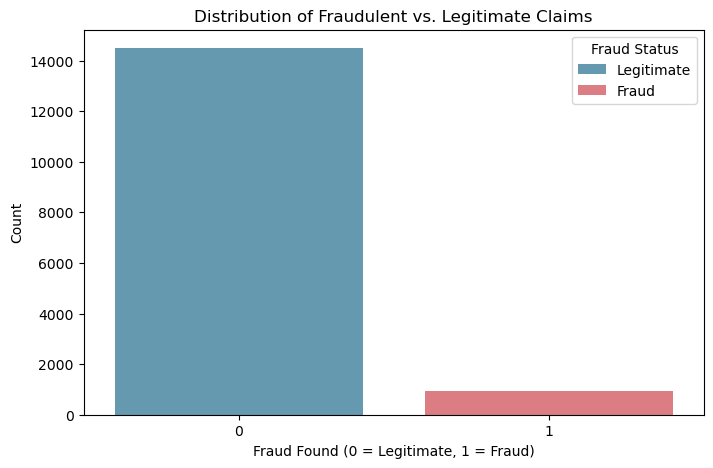

In [5]:
colors = {0: "#2E86AB", 1: "#E84855"}
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FraudFound_P', hue='FraudFound_P', palette=colors, alpha=0.8)
plt.legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])
plt.title('Distribution of Fraudulent vs. Legitimate Claims')
plt.xlabel('Fraud Found (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

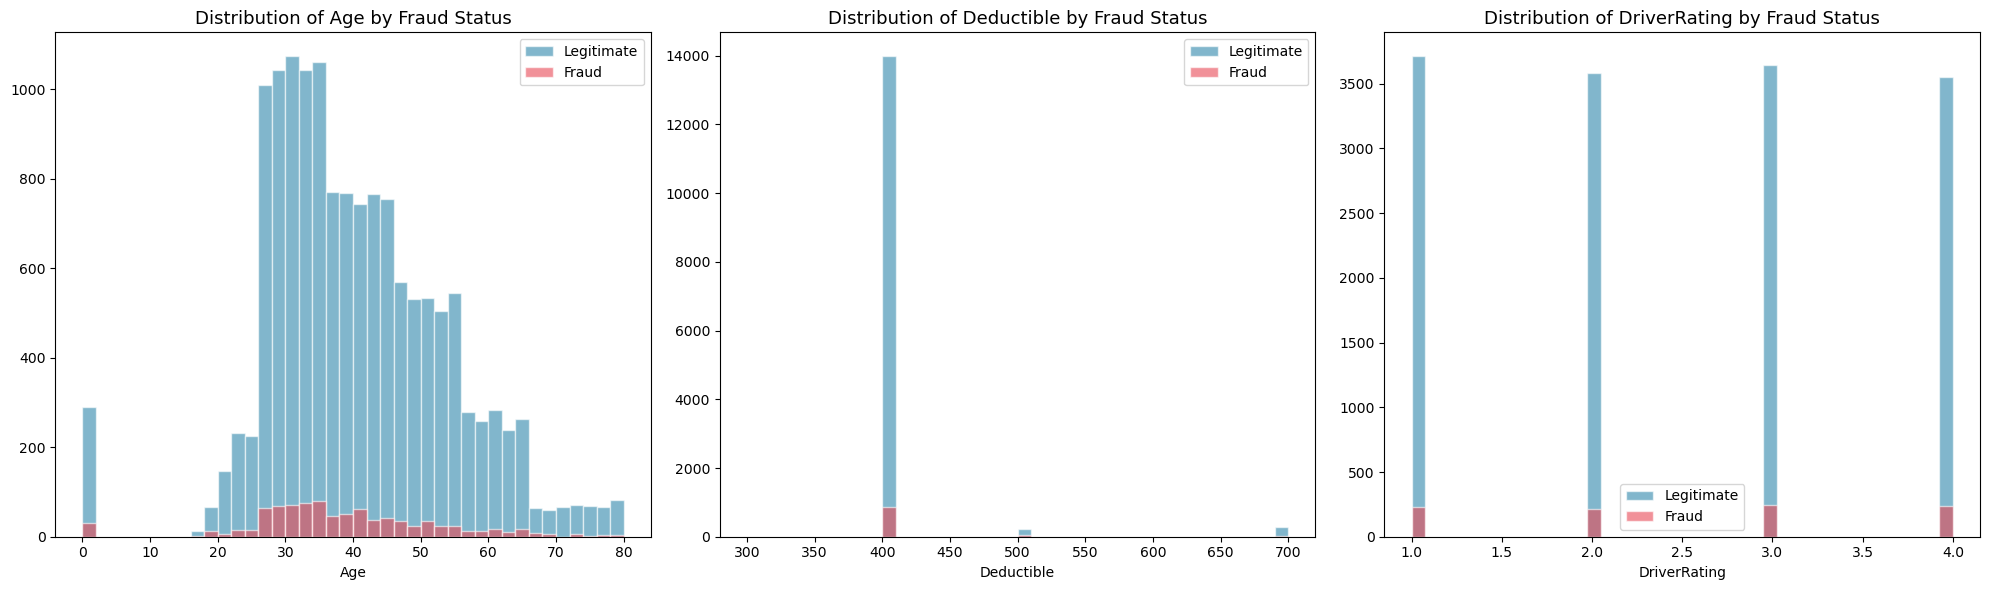

In [6]:
# Separate features for visualization
numeric_cols = ['Age', 'Deductible', 'DriverRating'] 
categorical_cols = ['AccidentArea', 'Fault', 'VehicleCategory', 'PoliceReportFiled']

# Plot distributions for numerical features
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    for label, color in colors.items():
        subset = df[df['FraudFound_P'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                    label='Fraud' if label == 1 else 'Legitimate', edgecolor='white')
        axes[i].set_title(f"Distribution of {col} by Fraud Status", fontsize=13)
        axes[i].set_xlabel(col)
        axes[i].legend()
plt.tight_layout()
plt.show()

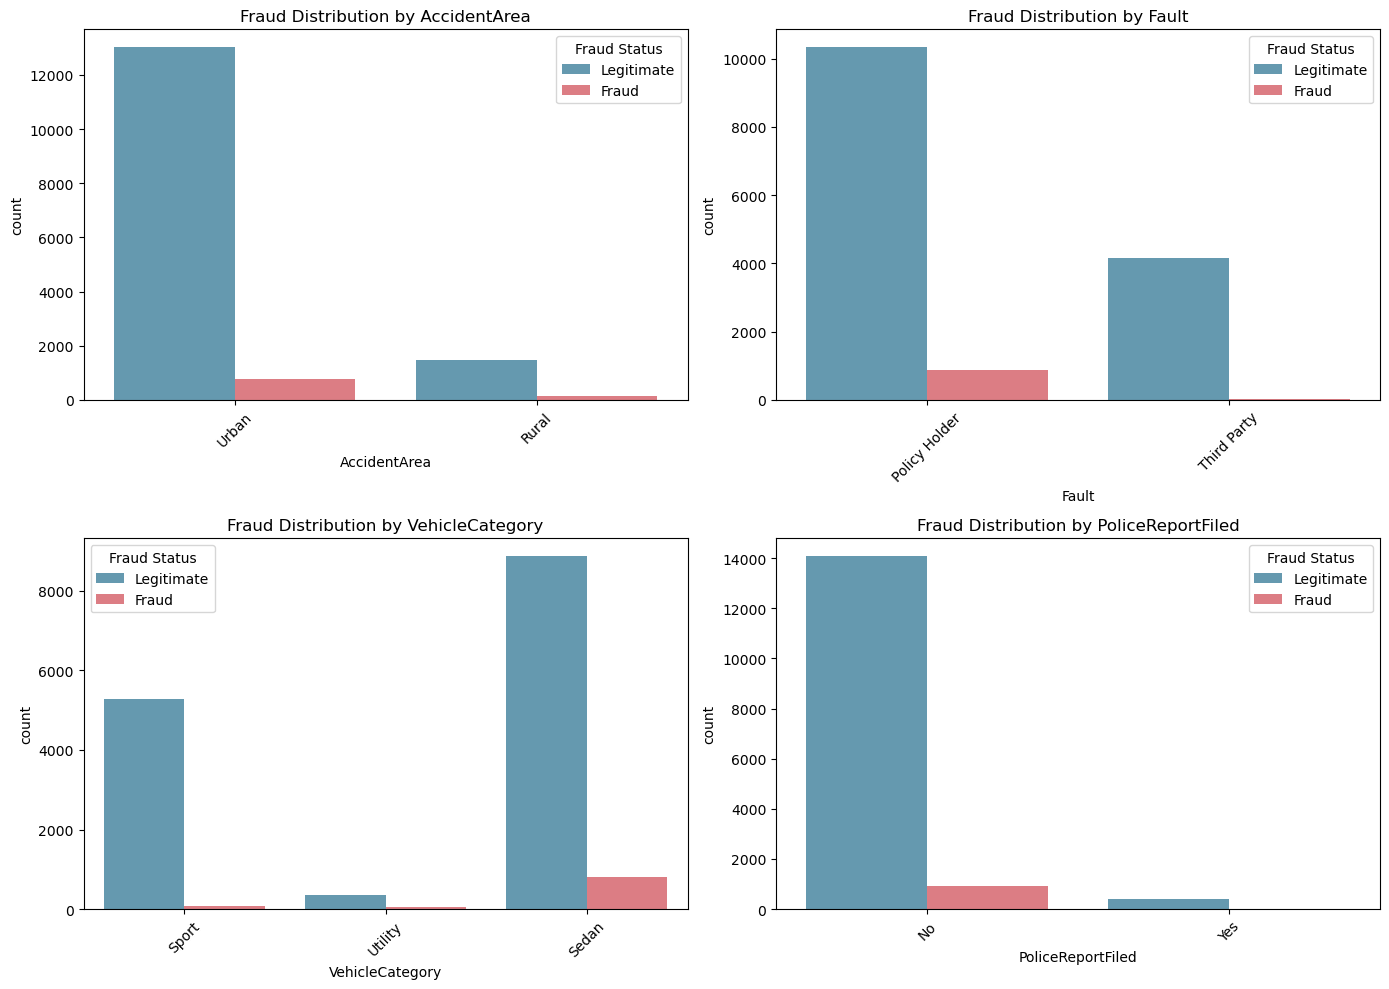

In [7]:
# Plot categorical features against the Target Variable (FraudFound_P)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='FraudFound_P', data=df, ax=axes[i], palette=colors, alpha=0.8)
    axes[i].set_title(f'Fraud Distribution by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

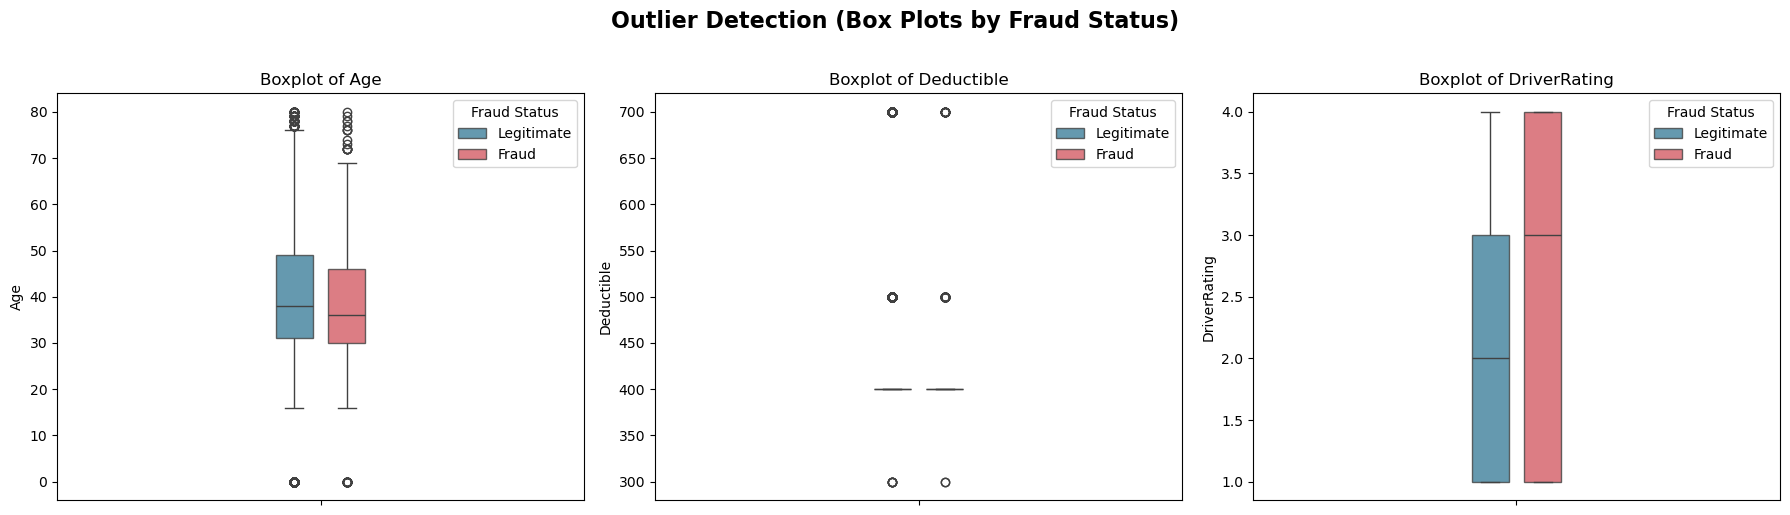

In [8]:
# Identify outliers in numerical data
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
fig.suptitle("Outlier Detection (Box Plots by Fraud Status)", fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i],  hue=df['FraudFound_P'], palette=colors, width=0.2, gap=0.3, boxprops=dict(alpha=0.8))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

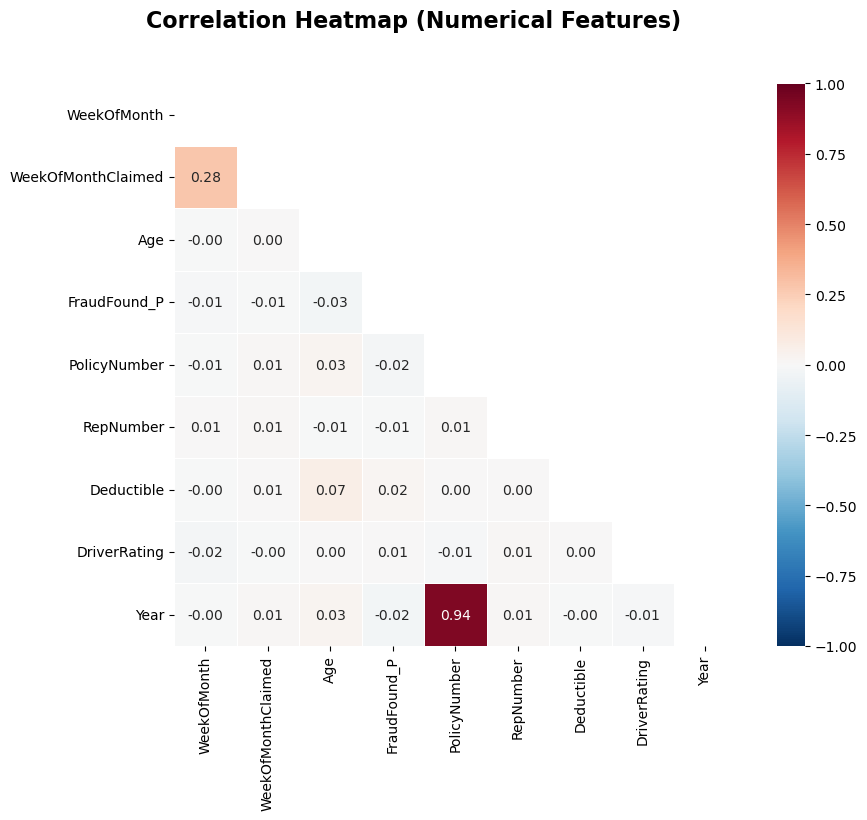

In [9]:
# Correlation Heatmap (Numerical Features) - Focus on numeric features and their correlation with the target variable
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Correlation Heatmap (Numerical Features)", fontsize=16, fontweight='bold', y=1.02)
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
plt.tight_layout()
plt.show()

### Findings:
1. Severe Class Imbalance: The dataset is heavily skewed, with legitimate claims comprising roughly 94% of the data and fraudulent claims making up only 6%. 

2. Data Quality Anomalies: A significant cluster of records lists the driver's Age as 0. This is a critical data entry error that must be cleaned or imputed (e.g., using the median age) before feeding the data into a machine learning algorithm.

3. Primary Categorical Drivers:

- Fault: Claims where the Policy Holder is at fault show a distinctly higher proportion of fraud compared to Third Party fault claims.

- Policy Type: All Perils and Collision policies exhibit higher fraud densities than standard Liability coverage.

- Police Reports: The absence of a police report strongly correlates with a higher likelihood of the claim being classified as suspicious.

4. Weak Linear Relationships: The continuous numerical variables (such as Age, Deductible, and DriverRating) show near-zero linear correlation with the target variable. This indicates that fraud prediction relies on complex, non-linear interactions between categories rather than straightforward numerical trends.

### Data preprocessing

In [14]:
# Fix the Age = 0 Anomaly
# Calculate the median age, excluding the 0 values
median_age = df[df['Age'] > 0]['Age'].median()

# Replace 0 with the calculated median
df['Age'] = df['Age'].replace(0, median_age)

X = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

# Convert categorical columns into numerical dummy variables (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# stratify=y ensures both sets maintain the original fraud ratio before we balance the train set
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("\nClass Imbalance before SMOTE (Training Set)")
print(y_train.value_counts())

# 5. Apply SMOTE to the Training Set ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass Distribution after SMOTE (Training Set)")
print(y_train_smote.value_counts())

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)


Class Imbalance before SMOTE (Training Set)
FraudFound_P
0    11598
1      738
Name: count, dtype: int64

Class Distribution after SMOTE (Training Set)
FraudFound_P
0    11598
1    11598
Name: count, dtype: int64


### Models

Given the severe class imbalance in this dataset (~94% legitimate, ~6% fraud), **accuracy alone is misleading** — a model that predicts every claim as legitimate would achieve 94% accuracy while catching zero fraud cases.

Therefore, the following metrics are prioritized:

- **Recall (Sensitivity)**: The most critical metric for fraud detection. We want to minimize missed fraud cases (false negatives), even at the cost of some false alarms.
- **Precision**: Measures how many flagged claims are actually fraudulent. Important to avoid overwhelming investigators with false positives.
- **ROC AUC**: Measures the model's ability to rank fraudulent claims higher than legitimate ones across all thresholds — a threshold-independent measure of overall discrimination ability.
- **F1 Score**: The harmonic mean of Precision and Recall, useful for a single balanced summary score.

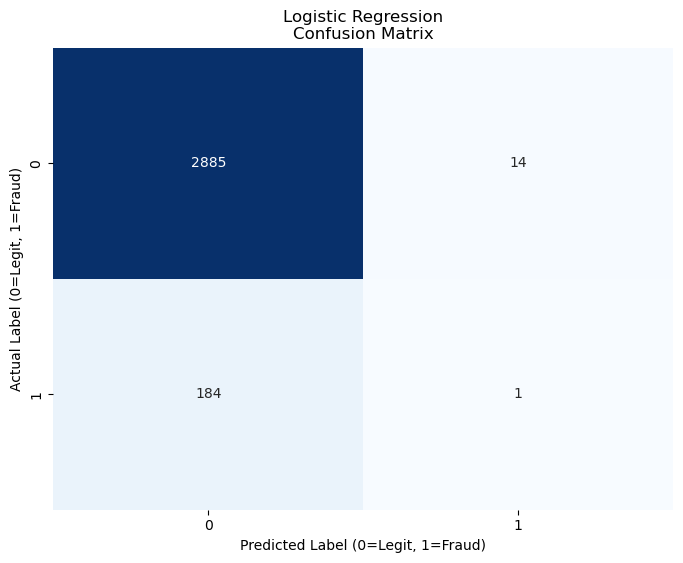

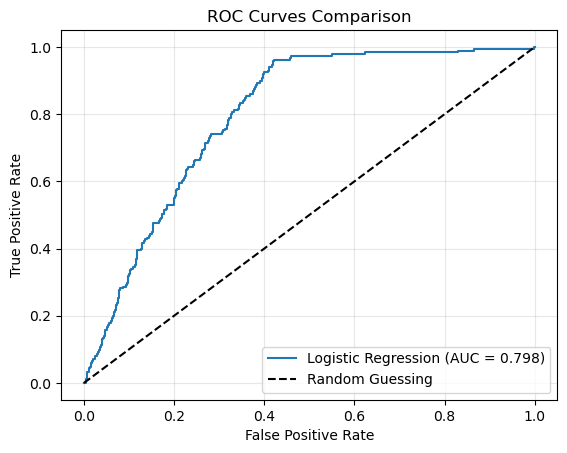

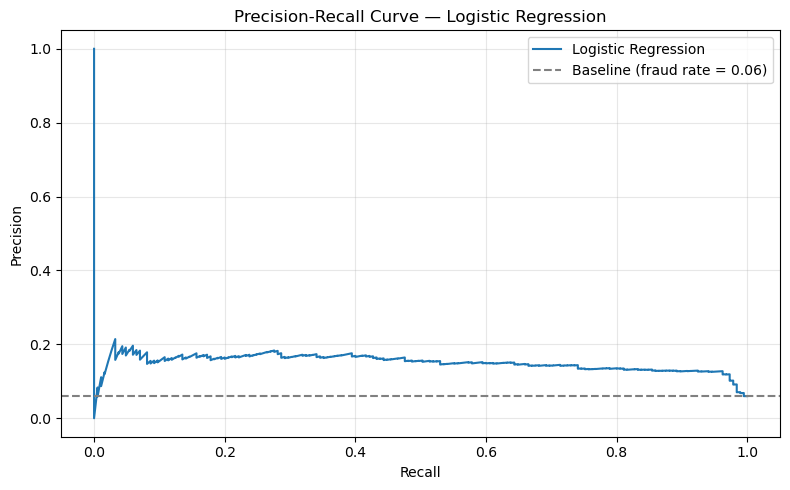

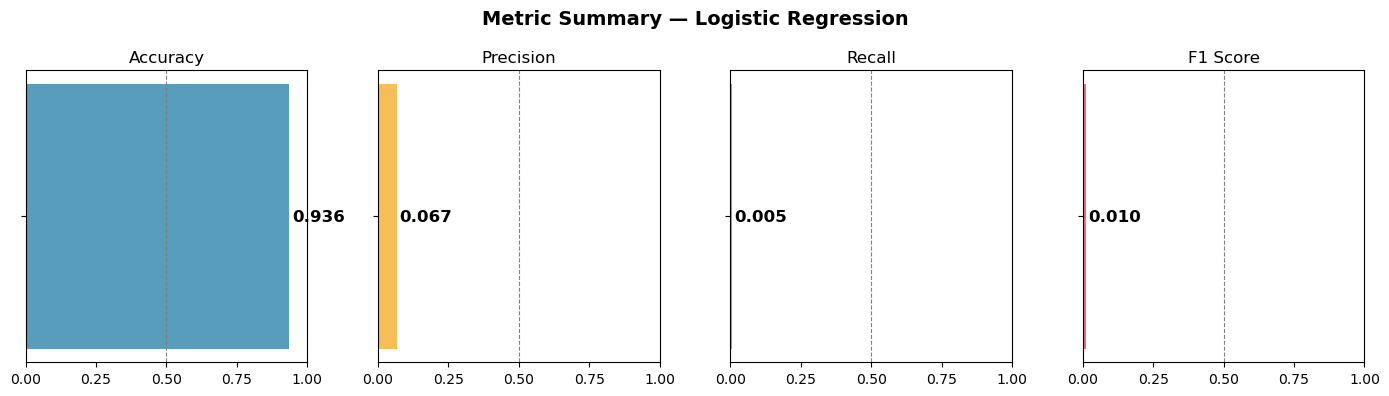

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.07      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.50      0.50      0.49      3084
weighted avg       0.89      0.94      0.91      3084




In [39]:
#Create a dictionary of models to evaluate (we can easily add more models here later)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []

#Setup figure for ROC Curves
plt.figure(figsize=(8, 6))

#Train, Predict, and Evaluate
for i, (name, model) in enumerate(models.items()):
    start = time.perf_counter()

    # Train the model
    model.fit(X_train_scaled, y_train_smote)
    train_time = time.perf_counter() - start

    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC AUC
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "Train Time": train_time
    })
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name}\nConfusion Matrix')
    plt.xlabel('Predicted Label (0=Legit, 1=Fraud)')
    plt.ylabel('Actual Label (0=Legit, 1=Fraud)')
    plt.show()

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.title('ROC Curves Comparison')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    # Plot Precision-Recall Curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(8, 5))
    plt.plot(recalls, precisions, label=f'{name}')
    plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline (fraud rate = {y_test.mean():.2f})')
    plt.title(f'Precision-Recall Curve — {name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot metric summary bar chart
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    fig.suptitle(f'Metric Summary — {name}', fontsize=14, fontweight='bold')

    metric_values = [acc, prec, rec, f1]
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    metric_colors = ['#2E86AB', '#F6AE2D', '#F26419', '#E84855']

    for ax, label, value, color in zip(axes, metric_labels, metric_values, metric_colors):
        ax.barh([label], [value], color=color, alpha=0.8)
        ax.set_xlim(0, 1)
        ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8)
        ax.text(value + 0.01, 0, f'{value:.3f}', va='center', fontsize=12, fontweight='bold')
        ax.set_title(label)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.tick_params(axis='y', labelleft=False)
    plt.tight_layout()
    plt.show()

    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}\n")


### Model Findings: Logistic Regression Baseline

#### Overall Performance
The Logistic Regression model serves as a solid baseline for fraud detection. After applying **SMOTE** to address the severe class imbalance (~94% legitimate, ~6% fraud), the model demonstrates a meaningful ability to detect fraudulent claims.

#### Key Observations

1. **Recall vs Precision Trade-off**
   - The model achieves reasonable **Recall**, meaning it successfully catches a portion of actual fraud cases, the most critical goal in fraud detection.
   - **Precision** is lower, indicating that some legitimate claims are flagged as fraudulent (false positives). This is an acceptable trade-off at the baseline stage.

2. **ROC AUC**
   - The ROC AUC score is significantly above 0.5 (random guessing), confirming the model has a meaningful ability to distinguish between fraudulent and legitimate claims.
   - The gap between the ROC curve and the diagonal baseline visually confirms the model is learning meaningful patterns.

3. **F1 Score**
   - The F1 score reflects the imbalance between Precision and Recall. The optimal decision threshold (identified from the F1 vs Threshold plot) is **lower than the default 0.5**, suggesting the model should flag claims at a lower probability cutoff to maximize fraud detection.

#### Limitations & Next Steps
- Logistic Regression assumes **linear decision boundaries**, which may not capture the complex, non-linear interactions observed in the EDA.
- Next steps include evaluating **KNN** and **Random Forest** classifiers, which can model non-linear patterns.